# EN3150 Assignment 03 — Feature Four
University of Moratuwa

ARUNIYA R. (230059T); MUHAMATH M.A.A.A. (230416L); PIRIYATHARSAN M. (230491J); SNEKAN S. (230620G).

This self-contained submission contains the completed project's implementation and **recorded results from the completed experimental run**. All reported training and test measurements come from embedded original CSV/JSON files. Synthetic forward checks use untrained weights and do not reproduce those accuracy measurements.

**Run All is safe by default:** no dataset download, training, optimizer experiment, checkpoint evaluation, or latency benchmark is executed. Only evidence checks and CPU forward/parameter checks run. Images and trained checkpoints are not embedded. No local project modules are required.

## 1. Dependencies and reproducibility
Use a Python environment with the following recorded project dependencies and a Jupyter frontend. Installation is not executed by this notebook.
```text
# Install CUDA-enabled torch/torchvision first (see README), or use CPU wheels.
torch==2.13.0
torchvision==0.28.0
numpy==2.5.2
pandas==3.0.6
scikit-learn==1.9.0
matplotlib==3.11.1
Pillow==12.3.0
```
The completed run used FP32. Deterministic seeds and the same saved sample membership are retained; timings can vary across hardware and library builds.

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import random, json, hashlib, time, platform, io, base64, zlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import EuroSAT
from torchvision.models import mobilenet_v2, efficientnet_b0, MobileNet_V2_Weights, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
ROOT = Path("FeatureFour_A03_work")  # relative, separate reproduction directory
ALLOW_FULL_EXPERIMENTS = False
RUN_DATA_PREPARATION = False
RUN_OPTIMIZER_EXPERIMENT = False
RUN_CUSTOM_TRAINING = False
RUN_PRETRAINED_TRAINING = False
RUN_CHECKPOINT_EVALUATION = False
SEED = 3150
BATCH_SIZE = 128
CUSTOM_EPOCHS = 25
OPTIMIZER_EPOCHS = 10
HEAD_EPOCHS = 2
FINETUNE_EPOCHS = 8
IMAGE_SIZE = 64
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
OPTIMIZERS = {"sgd": {"lr": 0.01, "momentum": 0.0},
              "momentum": {"lr": 0.01, "momentum": 0.9},
              "adam": {"lr": 0.001, "momentum": 0.0}}

In [2]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.set_num_threads(4)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)

def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def log(message):
    with (ROOT / "RUN_LOG.md").open("a", encoding="utf-8") as f:
        f.write(f"\n- {message}\n")

seed_everything()
print("Seed:", SEED, "| Full training enabled:", ALLOW_FULL_EXPERIMENTS)

Seed: 3150 | Full training enabled: False


## 2. Embedded recorded evidence
The compressed payload below is data, not executable code: exact original split and result file bytes, including histories, per-sample test predictions, confusion matrices, architecture tables and run metadata. SHA-256 checks detect accidental changes. It is read in memory and never copied over new experiment results.

In [3]:
RECORDED_SHA256 = {'data/splits/content_audit.json': '29f5a92c2dc5dd14a37b3bb6d0cadff8b5c56b396002204ea7856c3404652cd2', 'data/splits/dataset_info.json': '1387bf1b0e6ebc54a15d3572be13e265cab0c2fba298f4ab4e21b31147a51273', 'data/splits/sample_manifest.json': '809e2be4de4883f540ddcf66eab6e9ef4d588b936ea2c587951a60626b555fad', 'data/splits/test_indices.json': 'ae59898e623d89ac1701b98eddb1f7768924393ceef11a8c4d8f81e7f23838da', 'data/splits/train_indices.json': 'ac44fe4983f2fb2c890f86a50b885e8f0bef5bb7e218f552b65fc9a3fda670e8', 'data/splits/val_indices.json': '9b42809398fe6b23af6fdee7503657e39b366059bd9299c1f620b0212e54382f', 'results/raw/efficientnet_b0/classification_report.csv': 'd1bd841a1efb90a597f512501c58b28f0499c10a371192e32c83c7e7727f55fe', 'results/raw/efficientnet_b0/confusion_matrix.csv': '8a0ef2560c1769d8b22f5fdeae09c4c0462d6622967459fa37b72b42bec0ffa1', 'results/raw/efficientnet_b0/history.csv': 'aaf51d912aa22cb94039993db178f9cebef19948375457560e54e28e9e0e0b17', 'results/raw/efficientnet_b0/metrics.json': '0a7fa2a66ec774bd404e667d74143e7ddac876e8e32341b70555caca646ab850', 'results/raw/efficientnet_b0/run.json': 'c0aa16bca99ef461643d65c36f43d5b2c6adef7ce96bb929bbbda9442159c0af', 'results/raw/efficientnet_b0/test_predictions.csv': 'da979ac5606069716adf94e718e44861c82a2a2f121361b84fcd4a102c63f216', 'results/raw/mobilenet_v2/classification_report.csv': '846535ac99b25664dcc527d5bf21ab2da1081d9cdf6c724a643055daebfcf718', 'results/raw/mobilenet_v2/confusion_matrix.csv': '85ad4aec2fab7ef6bc42b507f04059aa5bbb61a73ef83d862c7616ce4db9646a', 'results/raw/mobilenet_v2/history.csv': '3b306d046d725c4922a80c74a15777e226ad900fe2d2870da4a5bf389b9148d4', 'results/raw/mobilenet_v2/metrics.json': 'd45e1f7fd85556cdae76add8733ccefc9781c9e452682ff92b25c025903fe30c', 'results/raw/mobilenet_v2/run.json': 'bfec78e80d27038ed9849c8852421c5bb9ac71ecd52e42b584431c91808bdff1', 'results/raw/mobilenet_v2/test_predictions.csv': 'ef0b249a464be6f557b4f88c5a3318f819248afe5d53aac01d9440ab7c4a554c', 'results/raw/model_a/classification_report.csv': '32034a899dfe5443a9ed2ded1f328e0129f63a6042316b63b00ff46c90aa383b', 'results/raw/model_a/confusion_matrix.csv': 'c5fdc2558a21edb5af1964c60dd033976c11144cbe0adab042c42abfec87c298', 'results/raw/model_a/history.csv': '4a4a0c9b1cf0a92c4595a01db8ed9b2056534154caa47dfa97b7113510f10a98', 'results/raw/model_a/metrics.json': '4f41358c3ef60017f121ae68ccf588b67cb29047d93c0e74734063e8d07e39b8', 'results/raw/model_a/run.json': '7ed2893d075d3f4eaac0f121b9ceca4054b3cc647da9adeaf9eb9b8526e466f4', 'results/raw/model_a/test_predictions.csv': '8317d4ba9c082be6dc1216197a5a423affacca6307089df4968fef7619faa58d', 'results/raw/model_b/classification_report.csv': '082f311d6d3f44feed7135c0ce0d83faf7c1f9ac382c1193976a221248cdd4f3', 'results/raw/model_b/confusion_matrix.csv': '0c0957c6653c7148b16f2df54da4ccc691fc7d6de8822162b573b1220ae1787b', 'results/raw/model_b/history.csv': '8710de57514b6f79577318746ada20291c883c4866461ff75340cbd4cd804f58', 'results/raw/model_b/metrics.json': '290b6da76bf232f16055746deabdee4d66e73e425e80b7fb76be777ad7b7d3ab', 'results/raw/model_b/run.json': 'e55b27f301c49cb481395449844a73dfcf0b7877ca8091bba3efc3cea7276048', 'results/raw/model_b/test_predictions.csv': 'c2a110175de2b841a80389ff9ad4d97723c8320c96c6ec961236c493cef973a2', 'results/raw/optimizer_adam/history.csv': '6f377db771907fba0c015a415e884eb0360599536338cde50d920a0db9aa341b', 'results/raw/optimizer_adam/run.json': '07a682e74643fe06b9c5740d0829bbf46a54e1073ee63dcd2a1c99a567129413', 'results/raw/optimizer_momentum/history.csv': '99e063b19bcbfbacda80fae0c725428be45e2d57f7a1f1b3c39173b79f51efae', 'results/raw/optimizer_momentum/run.json': '9ee2b1ca3070e87bf3052f76234c1d19095906020ad13c0cab251e8de9432cbd', 'results/raw/optimizer_sgd/history.csv': '601c8d746db6df7dfe1cff359a94b5db5195ab3a5f063e30130222d939549d62', 'results/raw/optimizer_sgd/run.json': 'a34c20e6cf5923838597e461cd7b47f921a7b5f8521e77619c54d9bc23c89dba', 'results/raw/selected_optimizer.json': '79653ef510b0e724fffd7636490ce1bcee6e2477e453d425f78fd881457c6644', 'results/raw/smoke/history.csv': '63a40f7873bcd2f166ffbef21f92b58a427da7b5aa18eb4431e1aa32b128f086', 'results/raw/smoke/run.json': '7731625c63bfda6d4efac508dfc451f796305c6b02c356fbe58ee52016fc40ed', 'results/raw/smoke/sanity.json': '8354c52f9bb65ea3c57a7688d0e304ca7cde09fdb250b33f3855d48b1e895b31', 'results/tables/convolution_savings.csv': '0f099d9597a56e9c3dd4a9728cbbd6b7d48b6587838d9dd0c2a0a70166783e63', 'results/tables/custom_models.csv': '88bdb63b28a612726439a581b1b7409a498035295146b427fec948da37bbf64f', 'results/tables/efficientnet_b0_architecture.csv': '1f77d3bb632997eb3de1ae61b6fc0cd052c2edf76852be7d9df4d785e315e682', 'results/tables/final_comparison.csv': 'f27c7f943d61127074e9249581762dc72b13efec6ef163f9488b9d209b6f38fb', 'results/tables/mobilenet_v2_architecture.csv': 'c4e85887b41e8e7b09f9b6c9b771d14bb8ae5a284dd3c6e701803297a2617f2b', 'results/tables/model_a_architecture.csv': '72eaf2e218f489fcf594f54ccb6cb21467bb3763b0d6577afdb69ebaf29c69f1', 'results/tables/model_b_architecture.csv': '8be5d8b08498fd1aa121da2060e4e88c4923824b9b3d84ee55bb410992fd9a42', 'results/tables/model_inspection.csv': 'aac8b60b18cad8bd6f31fea7b8774b2c03ac5a05ded24cfaecabc150438a788b', 'results/tables/optimizer_comparison.csv': '5f718d813f96a9120a313f0cae5a1066b863b7db301cfe26692d79ab863e35ae', 'results/tables/pretrained_models.csv': 'a13e79029c13a9da98c9158b4f7e217d44f52350cd6d6c941a12aad54607467b', 'results/verification.json': '585bf7dfdefb6d40e527fdbb3539b5905f62f668cc999dc88b05fb080fb376bc'}
_RECORDED_PAYLOAD = '...'
RECORDED = {k: base64.b64decode(v) for k, v in json.loads(zlib.decompress(base64.b64decode(_RECORDED_PAYLOAD))).items()}
assert all(hashlib.sha256(v).hexdigest() == RECORDED_SHA256[k] for k, v in RECORDED.items())
def recorded_json(path):
    return json.loads(RECORDED[path])
def recorded_csv(path, **kwargs):
    return pd.read_csv(io.BytesIO(RECORDED[path]), **kwargs)
print(f"Verified {len(RECORDED)} embedded evidence files.")

Verified 51 embedded evidence files.


## 3. EuroSAT loading, saved 70/15/15 split and preprocessing
The RGB dataset has 27,000 images at 64 × 64 pixels. Stratification gives 18,900 training, 4,050 validation and 4,050 test images. The following check reproduces the index calculation against the embedded manifest, without loading images. Index disjointness is checked now; the pixel-duplicate audit is a recorded result from dataset preparation. Training alone receives horizontal flips (probability 0.5). All splits use fixed ImageNet normalization; no normalization statistics are fitted to held-out images.

In [4]:
dataset_info = recorded_json("data/splits/dataset_info.json")
manifest = recorded_json("data/splits/sample_manifest.json")
labels = np.array([s["label"] for s in manifest])
split_indices = {s: recorded_json(f"data/splits/{s}_indices.json") for s in ("train", "val", "test")}
a, holdout = train_test_split(np.arange(len(labels)), test_size=.30, random_state=SEED, stratify=labels)
b, c = train_test_split(holdout, test_size=.5, random_state=SEED, stratify=labels[holdout])
assert [len(split_indices[s]) for s in split_indices] == [18900, 4050, 4050]
assert sorted(sum(split_indices.values(), [])) == list(range(27000))
for s, generated in zip(split_indices, (a, b, c)):
    assert split_indices[s] == sorted(generated.tolist())
    assert RECORDED_SHA256[f"data/splits/{s}_indices.json"] == dataset_info["split_sha256"][s+"_indices"]
display(pd.DataFrame(dataset_info["class_counts"]).T)
print("Recorded content audit:", recorded_json("data/splits/content_audit.json"))

Recorded content audit: {'unique_images': 27000, 'cross_split_identical_images': 0}


,total,train,val,test
AnnualCrop,3000,2100,450,450
Forest,3000,2100,450,450
HerbaceousVegetation,3000,2100,450,450
Highway,2500,1750,375,375
Industrial,2500,1750,375,375
Pasture,2000,1400,300,300
PermanentCrop,2500,1750,375,375
Residential,3000,2100,450,450
River,2500,1750,375,375
SeaLake,3000,2100,450,450


In [5]:
def prepare_data():
    if not RUN_DATA_PREPARATION:
        raise RuntimeError("Dataset preparation is disabled")
    # Materialize the original exact split files, never overwrite different files.
    for key, content in RECORDED.items():
        if key.startswith("data/splits/"):
            target = ROOT / key
            target.parent.mkdir(parents=True, exist_ok=True)
            if target.exists():
                assert target.read_bytes() == content, f"Existing split evidence differs: {key}"
            else:
                target.write_bytes(content)
    ds = EuroSAT(str(ROOT / "data"), download=True)
    labels = np.asarray(ds.targets)
    manifest = [{"path": str(__import__('pathlib').Path(p).relative_to(ds.root)),
                 "label": int(y)} for p, y in ds.samples]
    splitdir = ROOT / "data/splits"
    splitdir.mkdir(parents=True, exist_ok=True)
    manifest_path = splitdir / "sample_manifest.json"
    if manifest_path.exists():
        assert [(r["path"].replace("\\", "/"), r["label"]) for r in read_json(manifest_path)] == [(r["path"].replace("\\", "/"), r["label"]) for r in manifest], "Dataset ordering changed"
    else:
        write_json(manifest_path, manifest)
    paths = [splitdir / f"{s}_indices.json" for s in ("train", "val", "test")]
    if not any(p.exists() for p in paths):
        train, holdout = train_test_split(np.arange(len(ds)), test_size=0.30,
                                         random_state=SEED, stratify=labels)
        val, test = train_test_split(holdout, test_size=0.5,
                                   random_state=SEED, stratify=labels[holdout])
        for path, indices in zip(paths, (train, val, test)):
            write_json(path, sorted(indices.tolist()))
    assert all(p.exists() for p in paths), "Incomplete saved split; investigate before replacing"
    groups = [read_json(p) for p in paths]
    assert [len(g) for g in groups] == [18900, 4050, 4050]
    assert len(set(sum(groups, []))) == len(ds) == 27000
    assert sorted(sum(groups, [])) == list(range(len(ds)))
    counts = {name: {"total": int((labels == i).sum()),
               **{s: int((labels[idx] == i).sum()) for s, idx in zip(("train", "val", "test"), groups)}}
              for i, name in enumerate(ds.classes)}
    for c in counts.values():
        assert c["train"] == c["total"] * .70
        assert c["val"] == c["test"] == c["total"] * .15
    info = {"total_images": len(ds), "num_classes": len(ds.classes), "classes": ds.classes,
            "class_counts": counts, "split_sizes": dict(zip(("train", "val", "test"), map(len, groups))),
            "seed": SEED, "manifest_sha256": sha256(manifest_path),
            "split_sha256": {p.stem: sha256(p) for p in paths}}
    cache = ROOT / "data/rgb_uint8.pt"
    if not cache.exists():
        images = torch.empty((len(ds), 3, 64, 64), dtype=torch.uint8)
        content_hashes = []
        for i in range(len(ds)):
            im, _ = ds[i]
            arr = np.asarray(im)
            assert arr.shape == (64, 64, 3)
            images[i] = torch.from_numpy(arr.copy()).permute(2, 0, 1)
            content_hashes.append(hashlib.sha256(arr.tobytes()).hexdigest())
            if i % 5000 == 0:
                print(f"Decoded {i}/{len(ds)}", flush=True)
        # Stronger than index disjointness: detect pixel-identical images crossing sets.
        sets = [set(content_hashes[i] for i in g) for g in groups]
        overlaps = sum(len(sets[a] & sets[b]) for a, b in ((0, 1), (0, 2), (1, 2)))
        assert overlaps == 0, "Identical image content crosses split boundaries"
        write_json(splitdir / "content_audit.json", {"unique_images": len(set(content_hashes)),
                   "cross_split_identical_images": overlaps})
        torch.save({"images": images, "labels": torch.tensor(labels),
                    "manifest_sha256": info["manifest_sha256"]}, cache)
    write_json(splitdir / "dataset_info.json", info)
    print(info, flush=True)
    log("EuroSAT prepared: 27,000 RGB images; stratified 18,900/4,050/4,050 split; saved index and manifest hashes.")
    return info

def loaders(batch_size=BATCH_SIZE, seed=SEED, splits=("train", "val", "test")):
    info = read_json(ROOT / "data/splits/dataset_info.json")
    cache = torch.load(ROOT / "data/rgb_uint8.pt", weights_only=True)
    assert cache["manifest_sha256"] == info["manifest_sha256"]
    result = {}
    for split in splits:
        path = ROOT / f"data/splits/{split}_indices.json"
        assert sha256(path) == info["split_sha256"][f"{split}_indices"]
        idx = torch.tensor(read_json(path))
        ds = TensorDataset(cache["images"][idx], cache["labels"][idx])
        result[split] = DataLoader(ds, batch_size=batch_size, shuffle=split == "train",
                                  num_workers=0, pin_memory=torch.cuda.is_available(),
                                  generator=torch.Generator().manual_seed(seed))
    return result

def preprocess(x, device, training=False):
    x = x.to(device, non_blocking=True).float().div_(255)
    if training:
        flip = torch.rand((len(x), 1, 1, 1), device=device) < .5
        x = torch.where(flip, x.flip(-1), x)
    mean = x.new_tensor(MEAN)[None, :, None, None]
    std = x.new_tensor(STD)[None, :, None, None]
    return (x - mean) / std

## 4. Model A: standard convolution CNN
Four Conv–BatchNorm–ReLU–MaxPool blocks use channels 3→24→48→96→128, followed by global average pooling and a ten-class linear layer. ReLU is a simple elementwise maximum that avoids exponential operations and is widely supported by inference hardware. Actual latency still depends on kernels, memory traffic and device support.

In [6]:
class ModelA(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        blocks = []
        channels = [3, 24, 48, 96, 128]
        for cin, cout in zip(channels[:-1], channels[1:]):
            blocks.append(nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                          nn.BatchNorm2d(cout), nn.ReLU(), nn.MaxPool2d(2)))
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.classifier(self.flatten(self.pool(self.features(x))))

## 5. Model B: depthwise separable CNN
The first block remains a standard convolution. Later blocks replace standard convolution with depthwise spatial filtering followed by pointwise channel mixing, each with BatchNorm and ReLU. Global pooling avoids a large flattened classifier.

For a bias-free convolution with kernel width $k$, input channels $C_i$, output channels $C_o$ and output spatial size $H_oW_o$:
$$P_{standard}=k^2 C_i C_o,\qquad MAC_{standard}=H_oW_o k^2 C_i C_o.$$
$$P_{DS}=k^2 C_i+C_i C_o,\qquad MAC_{DS}=H_oW_o(k^2 C_i+C_i C_o).$$
$$P_{DS}/P_{standard}=1/C_o+1/k^2.$$
BatchNorm contributes two trainable values per channel. A biased linear layer has $(C_i+1)C_o$ parameters. Running BatchNorm statistics are buffers, not trainable parameters. The model constructor and smoke checks enforce the sub-100,000 limit.

In [7]:
class DepthwiseSeparableConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(nn.Conv2d(cin, cin, 3, padding=1, groups=cin, bias=False),
                         nn.BatchNorm2d(cin), nn.ReLU(),
                         nn.Conv2d(cin, cout, 1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU())

class ModelB(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Sequential(nn.Conv2d(3, 24, 3, padding=1, bias=False),
                          nn.BatchNorm2d(24), nn.ReLU(), nn.MaxPool2d(2)),
            nn.Sequential(DepthwiseSeparableConv(24, 48), nn.MaxPool2d(2)),
            nn.Sequential(DepthwiseSeparableConv(48, 96), nn.MaxPool2d(2)),
            nn.Sequential(DepthwiseSeparableConv(96, 128), nn.MaxPool2d(2)))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(128, num_classes)
        assert sum(p.numel() for p in self.parameters() if p.requires_grad) < 100000

    def forward(self, x):
        return self.classifier(self.flatten(self.pool(self.features(x))))

## 6. MobileNetV2, EfficientNet-B0 and transfer learning
The completed runs used ImageNet MobileNetV2 V2 weights and EfficientNet-B0 V1 weights. Their final classifiers are replaced by ten-output linear layers. Each run trains the head for two epochs at Adam learning rate 0.001, then the whole network for eight epochs at 0.0001. Frozen-feature BatchNorm statistics are held fixed during head training. The same 64 × 64 images and normalization are used for comparison. Smoke tests explicitly use `weights=False` to prevent downloads.

In [8]:
def pretrained_model(name, weights=True, num_classes=10):
    if name == "mobilenet_v2":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2 if weights else None)
    elif name == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1 if weights else None)
    else:
        raise ValueError(name)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model

def set_stage(model, head_only):
    for p in model.features.parameters():
        p.requires_grad_(not head_only)
    for p in model.classifier.parameters():
        p.requires_grad_(True)

def build_model(name, weights=True):
    if name == "model_a":
        return ModelA()
    if name == "model_b":
        return ModelB()
    return pretrained_model(name, weights=weights)

## 7. Parameter, MAC and resource calculations
Hooks count Conv2d and Linear MACs for one 64 × 64 RGB image. The arithmetic FLOP estimate is twice those MACs; it excludes normalization, activations, pooling, elementwise work and data movement. Saved checkpoint size includes buffers and serialization overhead, so it differs from four bytes times parameter count. Reported storage columns historically named KB/MB use binary KiB/MiB. CPU timing code is provided but is not run here.

In [9]:
def parameter_counts(model):
    return {"total_parameters": sum(p.numel() for p in model.parameters()),
            "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad)}

def architecture_table(model, name, save_table=True):
    rows, hooks = [], []
    device = next(model.parameters()).device
    def hook(label):
        def record(layer, args, out):
            macs = 0
            if isinstance(layer, nn.Conv2d):
                macs = out.numel() * (layer.in_channels // layer.groups) * layer.kernel_size[0] * layer.kernel_size[1]
            elif isinstance(layer, nn.Linear):
                macs = out.numel() * layer.in_features
            rows.append({"layer": label, "type": type(layer).__name__,
                "input_shape": str(list(args[0].shape)), "output_shape": str(list(out.shape)),
                "kernel": str(getattr(layer, "kernel_size", "-")),
                "in_channels": getattr(layer, "in_channels", getattr(layer, "in_features", "-")),
                "out_channels": getattr(layer, "out_channels", getattr(layer, "out_features", "-")),
                "stride": str(getattr(layer, "stride", "-")), "padding": str(getattr(layer, "padding", "-")),
                "groups": getattr(layer, "groups", "-"),
                "activation": type(layer).__name__ if isinstance(layer, (nn.ReLU, nn.ReLU6, nn.SiLU)) else "-",
                "parameters": sum(p.numel() for p in layer.parameters(recurse=False)),
                "trainable_parameters": sum(p.numel() for p in layer.parameters(recurse=False) if p.requires_grad),
                "conv_linear_macs": int(macs)})
        return record
    for label, layer in model.named_modules():
        if not list(layer.children()):
            hooks.append(layer.register_forward_hook(hook(label)))
    was_training = model.training
    model.eval()
    with torch.no_grad():
        output = model(torch.zeros(1, 3, 64, 64, device=device))
    for h in hooks:
        h.remove()
    model.train(was_training)
    assert output.shape == (1, 10)
    df = pd.DataFrame(rows)
    assert int(df.parameters.sum()) == parameter_counts(model)["total_parameters"]
    path = ROOT / f"results/tables/{name}_architecture.csv"
    if save_table:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
    return {**parameter_counts(model), "conv_linear_macs": int(df.conv_linear_macs.sum()),
            "conv_linear_flops_2mac": int(df.conv_linear_macs.sum()) * 2}

def inference_latency(model, repeats=100):
    """Batch-one FP32, warm model, host CPU only, four PyTorch threads.

    Input is already normalized. Excludes preprocessing and file I/O. This is
    a host benchmark, not a measurement on a microcontroller/edge accelerator.
    """
    original = next(model.parameters()).device
    model.cpu().eval()
    x = torch.zeros(1, 3, 64, 64)
    with torch.inference_mode():
        for _ in range(20):
            model(x)
        samples = []
        for _ in range(repeats):
            start = time.perf_counter()
            model(x)
            samples.append((time.perf_counter() - start) * 1000)
    model.to(original)
    return {"cpu_latency_ms_mean": sum(samples) / len(samples),
            "cpu_latency_ms_median": float(pd.Series(samples).median()),
            "cpu_latency_ms_p95": float(pd.Series(samples).quantile(.95)),
            "latency_repeats": repeats, "cpu_threads": torch.get_num_threads()}

def convolution_savings():
    rows = []
    for cin, cout in [(24, 48), (48, 96), (96, 128)]:
        standard, dsc = 9 * cin * cout, 9 * cin + cin * cout
        rows.append({"cin": cin, "cout": cout, "standard_weights": standard,
                     "depthwise_weights": 9 * cin, "pointwise_weights": cin * cout,
                     "dsc_weights": dsc, "reduction_percent": 100 * (1 - dsc / standard)})
    pd.DataFrame(rows).to_csv(ROOT / "results/tables/convolution_savings.csv", index=False)

## 8. Reusable training and optimizer definitions
SGD uses learning rate 0.01; SGD with momentum uses the same rate and momentum 0.9; Adam uses 0.001 with library-default betas. Weight decay is zero, with no scheduler or early stopping. Optimizer pilots run Model B for ten epochs from the same initial state and select by validation accuracy (validation loss breaks ties). Momentum accumulates gradient direction and can reduce oscillation; Adam also adapts per-parameter step sizes. This fixed-setting comparison does not establish a universal optimizer ranking.

Model A and B each train for 25 epochs with the selected optimizer. Checkpoint selection uses validation only. The test set is evaluated separately. The training entry point has an explicit disabled-by-default guard.

In [10]:
def make_optimizer(model, name, lr=None):
    settings = OPTIMIZERS[name]
    lr = settings["lr"] if lr is None else lr
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=0)
    return torch.optim.SGD(params, lr=lr, momentum=settings["momentum"], weight_decay=0)

def epoch_pass(model, loader, device, optimizer=None, head_only=False, max_batches=None):
    training = optimizer is not None
    model.train(training)
    if training and head_only:
        # Frozen feature BN running statistics must also stay fixed.
        model.features.eval()
    loss_sum, correct, count = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()
    with torch.set_grad_enabled(training):
        for batch, (images, labels) in enumerate(loader):
            if max_batches is not None and batch >= max_batches:
                break
            x = preprocess(images, device, training)
            y = labels.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite loss")
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.detach().item() * len(y)
            correct += (logits.detach().argmax(1) == y).sum().item()
            count += len(y)
    return loss_sum / count, correct / count

def train_run(model_name, run_name, optimizer_name="adam", epochs=25,
              batch_size=BATCH_SIZE, head_epochs=0, finetune_epochs=0,
              smoke=False):
    if not ALLOW_FULL_EXPERIMENTS:
        raise RuntimeError("Full training is disabled; explicitly opt in to reproduce")
    seed_everything()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    raw = ROOT / f"results/raw/{run_name}"
    raw.mkdir(parents=True, exist_ok=True)
    ckpt = ROOT / f"checkpoints/{run_name}.pt"
    ckpt.parent.mkdir(exist_ok=True)
    if (raw / "run.json").exists() and not smoke:
        raise FileExistsError(f"Completed run exists: {run_name}; preserve it or choose another run name")
    model = build_model(model_name).to(device)
    initial_hash = __import__('hashlib').sha256(b"".join(
        t.detach().cpu().numpy().tobytes() for t in model.state_dict().values())).hexdigest()
    data = loaders(batch_size, splits=("train", "val"))
    transfer = head_epochs > 0
    total_epochs = head_epochs + finetune_epochs if transfer else epochs
    history, stage_counts = [], {}
    best_acc, best_loss, best_epoch = -1, float("inf"), 0
    optimizer = None
    for epoch in range(1, total_epochs + 1):
        head_only = transfer and epoch <= head_epochs
        stage = "head" if head_only else ("finetune" if transfer else "full")
        if epoch == 1 or (transfer and epoch == head_epochs + 1):
            if transfer:
                set_stage(model, head_only)
            optimizer = make_optimizer(model, optimizer_name,
                                       (0.001 if head_only else 0.0001) if transfer else None)
            stage_counts[stage] = parameter_counts(model)["trainable_parameters"]
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()
        train_loss, train_acc = epoch_pass(model, data["train"], device, optimizer, head_only,
                                            2 if smoke else None)
        val_loss, val_acc = epoch_pass(model, data["val"], device, max_batches=2 if smoke else None)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        history.append({"epoch": epoch, "stage": stage, "optimizer": optimizer_name,
                        "lr": optimizer.param_groups[0]["lr"],
                        "momentum": OPTIMIZERS[optimizer_name]["momentum"],
                        "train_loss": train_loss, "val_loss": val_loss,
                        "train_accuracy": train_acc, "val_accuracy": val_acc,
                        "epoch_seconds": elapsed})
        if val_acc > best_acc or (val_acc == best_acc and val_loss < best_loss):
            best_acc, best_loss, best_epoch = val_acc, val_loss, epoch
            torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, ckpt)
        pd.DataFrame(history).to_csv(raw / "history.csv", index=False)
        print(f"{run_name} {epoch}/{total_epochs} {stage}: train={train_acc:.4f} val={val_acc:.4f} loss={val_loss:.4f} time={elapsed:.1f}s", flush=True)
    info = read_json(ROOT / "data/splits/dataset_info.json")
    metadata = {"model": model_name, "run": run_name, "seed": SEED, "epochs": total_epochs,
                "batch_size": batch_size, "optimizer": optimizer_name,
                "optimizer_settings": OPTIMIZERS[optimizer_name],
                "head_epochs": head_epochs, "finetune_epochs": finetune_epochs,
                "stage_trainable_parameters": stage_counts, "best_epoch": best_epoch,
                "best_val_accuracy": best_acc, "best_val_loss": best_loss,
                "avg_epoch_time_seconds": sum(r["epoch_seconds"] for r in history) / len(history),
                "checkpoint": str(ckpt.relative_to(ROOT)), "checkpoint_sha256": sha256(ckpt),
                "initial_state_sha256": initial_hash, "split_sha256": info["split_sha256"],
                "manifest_sha256": info["manifest_sha256"], "input_size": 64,
                "normalization": "ImageNet", "augmentation": "independent horizontal flip p=0.5",
                "device": str(device), "device_name": torch.cuda.get_device_name(0) if device.type == "cuda" else platform.processor(),
                "torch": torch.__version__, "torchvision": torchvision.__version__,
                "python": platform.python_version(), "precision": "FP32", "smoke": smoke,
                "pretrained_weights": {"mobilenet_v2": "IMAGENET1K_V2", "efficientnet_b0": "IMAGENET1K_V1"}.get(model_name),
                **parameter_counts(model)}
    write_json(raw / "run.json", metadata)
    log(f"Completed {run_name}: {total_epochs} epochs; best validation accuracy {best_acc:.6f} at epoch {best_epoch}; checkpoint `{metadata['checkpoint']}`.")
    return metadata

## 9. Evaluation: accuracy, macro precision, macro recall and confusion matrices
Accuracy is the fraction of correct predictions. Precision and recall are computed per class and then averaged equally over all ten classes (`zero_division=0`). Confusion-matrix rows are true classes and columns are predicted classes. Evaluation checks the checkpoint and split hashes before test inference. This code is supplied for reproduction and is not invoked during notebook validation.

In [11]:
def classification_metrics(truth, predicted, classes):
    labels = list(range(len(classes)))
    metrics = {"test_accuracy": accuracy_score(truth, predicted),
               "macro_precision": precision_score(truth, predicted, labels=labels, average="macro", zero_division=0),
               "macro_recall": recall_score(truth, predicted, labels=labels, average="macro", zero_division=0)}
    matrix = confusion_matrix(truth, predicted, labels=labels)
    report = classification_report(truth, predicted, labels=labels, target_names=classes,
                                   output_dict=True, zero_division=0)
    return metrics, matrix, report

def save(fig, folder, name):
    folder.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(folder / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(folder / f"{name}.png", dpi=220, bbox_inches="tight")
    plt.close(fig)

def curves(run):
    df = pd.read_csv(ROOT / f"results/raw/{run}/history.csv")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, metric, title in zip(axes, ("loss", "accuracy"), ("Cross-entropy loss", "Accuracy")):
        for split in ("train", "val"):
            ax.plot(df.epoch, df[f"{split}_{metric}"], label=split)
        ax.set(xlabel="Epoch", ylabel=title, title=run.replace("_", " "))
        ax.legend()
        ax.grid(alpha=.2)
    save(fig, ROOT / "results/figures", f"{run}_curves")

def confusion_figure(matrix, classes, name):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set(xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
           xticklabels=classes, yticklabels=classes, xlabel="Predicted class", ylabel="True class",
           title=name.replace("_", " "))
    plt.setp(ax.get_xticklabels(), rotation=55, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=7,
                    color="white" if matrix[i, j] > matrix.max() / 2 else "black")
    fig.colorbar(im, ax=ax, fraction=.046)
    save(fig, ROOT / "results/confusion_matrices", name)

def optimizer_plot():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for name in ("sgd", "momentum", "adam"):
        df = pd.read_csv(ROOT / f"results/raw/optimizer_{name}/history.csv")
        axes[0].plot(df.epoch, df.val_loss, label=name)
        axes[1].plot(df.epoch, df.val_accuracy, label=name)
    for ax, ylabel in zip(axes, ("Validation loss", "Validation accuracy")):
        ax.set(xlabel="Epoch", ylabel=ylabel)
        ax.legend()
        ax.grid(alpha=.2)
    save(fig, ROOT / "results/figures", "optimizer_comparison")

def final_plots(df):
    labels = [s.replace("_", " ") for s in df.model]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(labels, df.test_accuracy * 100, color=["#4c78a8", "#54a24b", "#eeca3b", "#f58518"])
    ax.set(ylabel="Test accuracy (%)", ylim=(0, 100))
    save(fig, ROOT / "results/figures", "final_accuracy")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].bar(labels, df.total_parameters)
    axes[0].set(ylabel="Parameters (log scale)", yscale="log")
    axes[1].bar(labels, df.model_size_mb)
    axes[1].set(ylabel="FP32 state dictionary (MiB)")
    for ax in axes:
        ax.tick_params(axis="x", rotation=20)
    save(fig, ROOT / "results/figures", "final_resources")

def evaluate(run):
    seed_everything()
    meta = read_json(ROOT / f"results/raw/{run}/run.json")
    assert not meta["smoke"]
    ckpt = ROOT / meta["checkpoint"]
    assert sha256(ckpt) == meta["checkpoint_sha256"]
    info = read_json(ROOT / "data/splits/dataset_info.json")
    assert meta["split_sha256"] == info["split_sha256"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_model(meta["model"], weights=False).to(device)
    model.load_state_dict(torch.load(ckpt, weights_only=True))
    model.eval()
    truth, predicted = [], []
    with torch.inference_mode():
        for x, y in loaders(splits=("test",))["test"]:
            predicted.extend(model(preprocess(x, device)).argmax(1).cpu().tolist())
            truth.extend(y.tolist())
    metrics, matrix, report = classification_metrics(truth, predicted, info["classes"])
    out = ROOT / f"results/raw/{run}"
    pd.DataFrame({"sample_index": read_json(ROOT / "data/splits/test_indices.json"),
                  "true_label": truth, "predicted_label": predicted}).to_csv(out / "test_predictions.csv", index=False)
    pd.DataFrame(report).T.to_csv(out / "classification_report.csv")
    pd.DataFrame(matrix, index=info["classes"], columns=info["classes"]).to_csv(out / "confusion_matrix.csv")
    row = {"model": meta["model"], **architecture_table(model, meta["model"]),
           "model_size_bytes": ckpt.stat().st_size, "model_size_kb": ckpt.stat().st_size / 1024,
           "model_size_mb": ckpt.stat().st_size / 1024**2,
           "avg_epoch_time_seconds": meta["avg_epoch_time_seconds"],
           "best_epoch": meta["best_epoch"], "epochs": meta["epochs"],
           **metrics, **inference_latency(model)}
    write_json(out / "metrics.json", row)
    confusion_figure(matrix, info["classes"], run)
    curves(run)
    return row

## 10. Complete experiment orchestration (disabled)
These functions contain the original experiment sequence. They write only to the relative reproduction directory. Recorded evidence remains separate in memory. Enabling reproduction deliberately incurs downloads and training; leave all flags false for submission review.

In [12]:
def optimizer_experiment(epochs=OPTIMIZER_EPOCHS, batch_size=BATCH_SIZE):
    rows = []
    for name in OPTIMIZERS:
        run_name = f"optimizer_{name}"
        path = ROOT / f"results/raw/{run_name}/run.json"
        meta = read_json(path) if path.exists() else train_run("model_b", run_name, name, epochs, batch_size)
        assert meta["epochs"] == epochs and meta["batch_size"] == batch_size
        h = pd.read_csv(path.parent / "history.csv")
        rows.append({"optimizer": name, **OPTIMIZERS[name], "epochs": epochs,
                     "best_val_accuracy": meta["best_val_accuracy"], "best_epoch": meta["best_epoch"],
                     "best_val_loss": meta["best_val_loss"], "final_val_accuracy": h.val_accuracy.iloc[-1],
                     "final_train_accuracy": h.train_accuracy.iloc[-1],
                     "final_val_loss": h.val_loss.iloc[-1],
                     "avg_epoch_time_seconds": meta["avg_epoch_time_seconds"],
                     "initial_state_sha256": meta["initial_state_sha256"]})
        curves(run_name)
    assert len({r["initial_state_sha256"] for r in rows}) == 1
    df = pd.DataFrame(rows).sort_values(["best_val_accuracy", "best_val_loss"], ascending=[False, True])
    df.to_csv(ROOT / "results/tables/optimizer_comparison.csv", index=False)
    selected = str(df.iloc[0].optimizer)
    write_json(ROOT / "results/raw/selected_optimizer.json", {"optimizer": selected,
               "criterion": "highest validation accuracy; ties resolved by lower validation loss", "epochs": epochs})
    optimizer_plot()
    log(f"Selected optimizer: {selected}; selection excludes test data.")

In [13]:
def train_custom_models(epochs=CUSTOM_EPOCHS, batch_size=BATCH_SIZE):
    if epochs < 20:
        raise ValueError("Final custom experiments require at least 20 epochs")
    selected = read_json(ROOT / "results/raw/selected_optimizer.json")["optimizer"]
    for name in ("model_a", "model_b"):
        path = ROOT / f"results/raw/{name}/run.json"
        if not path.exists():
            train_run(name, name, selected, epochs, batch_size)
        else:
            meta = read_json(path)
            assert meta["epochs"] == epochs and meta["batch_size"] == batch_size and meta["optimizer"] == selected

In [14]:
def train_pretrained_models(head_epochs=HEAD_EPOCHS, finetune_epochs=FINETUNE_EPOCHS, batch_size=BATCH_SIZE):
    assert head_epochs >= 1 and finetune_epochs >= 1
    for name in ("mobilenet_v2", "efficientnet_b0"):
        path = ROOT / f"results/raw/{name}/run.json"
        if not path.exists():
            train_run(name, name, "adam", batch_size=batch_size,
                      head_epochs=head_epochs, finetune_epochs=finetune_epochs)
        else:
            meta = read_json(path)
            assert meta["head_epochs"] == head_epochs and meta["finetune_epochs"] == finetune_epochs and meta["batch_size"] == batch_size

In [15]:
def evaluate_all():
    df = pd.DataFrame([evaluate(name) for name in ("model_a", "model_b", "mobilenet_v2", "efficientnet_b0")])
    df.to_csv(ROOT / "results/tables/final_comparison.csv", index=False)
    df.iloc[:2].to_csv(ROOT / "results/tables/custom_models.csv", index=False)
    df.iloc[2:].to_csv(ROOT / "results/tables/pretrained_models.csv", index=False)
    final_plots(df)
    print(df.to_string(index=False), flush=True)

In [16]:
if RUN_DATA_PREPARATION:
    prepare_data()
if any((RUN_OPTIMIZER_EXPERIMENT, RUN_CUSTOM_TRAINING, RUN_PRETRAINED_TRAINING, RUN_CHECKPOINT_EVALUATION)):
    if not ALLOW_FULL_EXPERIMENTS:
        raise RuntimeError("Explicit experiment opt-in is required")
    (ROOT / "results/tables").mkdir(parents=True, exist_ok=True)
if RUN_OPTIMIZER_EXPERIMENT:
    optimizer_experiment()
if RUN_CUSTOM_TRAINING:
    train_custom_models()
if RUN_PRETRAINED_TRAINING:
    train_pretrained_models()
if RUN_CHECKPOINT_EVALUATION:
    evaluate_all()
print("Full training and optimizer experiments skipped:", not ALLOW_FULL_EXPERIMENTS)

Full training and optimizer experiments skipped: True


## 11. Lightweight verification using untrained models
Only CPU forward passes and arithmetic/parameter counts are performed. No backward pass, optimizer step, downloaded weights or dataset inference is involved. These checks establish architecture compatibility, not trained accuracy.

In [17]:
seed_everything()
smoke_rows = []
for name, expected_parameters in [("model_a", 164962), ("model_b", 22426), ("mobilenet_v2", 2236682), ("efficientnet_b0", 4020358)]:
    model = build_model(name, weights=False).cpu().eval()
    with torch.inference_mode():
        output = model(preprocess(torch.zeros(2, 3, 64, 64, dtype=torch.uint8), torch.device("cpu")))
    assert output.shape == (2, 10) and torch.isfinite(output).all()
    counts = architecture_table(model, name, save_table=False)
    assert counts["total_parameters"] == expected_parameters
    assert counts["trainable_parameters"] == expected_parameters
    if name == "model_b":
        assert counts["trainable_parameters"] < 100000
        assert counts["conv_linear_macs"] == 6188288
    if name == "model_a":
        assert counts["conv_linear_macs"] == 30967040
    smoke_rows.append({"model": name, **counts, "forward_pass": "PASS"})
    del model
SMOKE_TESTS_PASSED = True
display(pd.DataFrame(smoke_rows))

,model,total_parameters,trainable_parameters,conv_linear_macs,conv_linear_flops_2mac,forward_pass
0,model_a,164962,164962,30967040,61934080,PASS
1,model_b,22426,22426,6188288,12376576,PASS
2,mobilenet_v2,2236682,2236682,24461312,48922624,PASS
3,efficientnet_b0,4020358,4020358,31979392,63958784,PASS


## 12. Recorded completed experiments and final comparison
The following tables are read directly from embedded original files. They are **recorded results**, not measurements from the smoke checks. The code also verifies saved predictions against accuracy, precision, recall and confusion matrices without running any model on the dataset.

In [18]:
comparison = recorded_csv("results/tables/final_comparison.csv")
optimizers = recorded_csv("results/tables/optimizer_comparison.csv")
assert optimizers.initial_state_sha256.nunique() == 1
for _, row in comparison.iterrows():
    name = row["model"]
    history = recorded_csv(f"results/raw/{name}/history.csv")
    meta = recorded_json(f"results/raw/{name}/run.json")
    assert len(history) == int(row.epochs) == meta["epochs"]
    assert meta["split_sha256"] == dataset_info["split_sha256"]
    if name in ("model_a", "model_b"):
        assert len(history) == 25 and len(history) >= 20
    predictions = recorded_csv(f"results/raw/{name}/test_predictions.csv")
    assert predictions.sample_index.tolist() == split_indices["test"]
    assert predictions.true_label.tolist() == labels[split_indices["test"]].tolist()
    metrics, cm, _ = classification_metrics(predictions.true_label, predictions.predicted_label, dataset_info["classes"])
    for key, value in metrics.items():
        assert np.isclose(row[key], value, rtol=0, atol=1e-12)
    saved_cm = recorded_csv(f"results/raw/{name}/confusion_matrix.csv", index_col=0)
    assert np.array_equal(cm, saved_cm.to_numpy())
print("Recorded final comparison (accuracy/precision/recall are fractions; KB/MB columns mean KiB/MiB):")
display(comparison)
print("Recorded optimizer comparison:")
display(optimizers.drop(columns=["initial_state_sha256"]))
print("Recorded transfer-learning stage parameter counts:")
display(pd.DataFrame({n: recorded_json(f"results/raw/{n}/run.json")["stage_trainable_parameters"] for n in ("mobilenet_v2", "efficientnet_b0")}))
print("Recorded predictions, confusion matrices, split membership and metrics agree.")

Recorded final comparison (accuracy/precision/recall are fractions; KB/MB columns mean KiB/MiB):
Recorded optimizer comparison:
Recorded transfer-learning stage parameter counts:
Recorded predictions, confusion matrices, split membership and metrics agree.


,model,total_parameters,trainable_parameters,conv_linear_macs,conv_linear_flops_2mac,model_size_bytes,model_size_kb,model_size_mb,avg_epoch_time_seconds,best_epoch,epochs,test_accuracy,macro_precision,macro_recall,cpu_latency_ms_mean,cpu_latency_ms_median,cpu_latency_ms_p95,latency_repeats,cpu_threads
0,model_a,164962,164962,30967040,61934080,670165,654.458008,0.639119,3.246210,18,25,0.942963,0.942538,0.942578,1.357825,1.21975,1.801870,100,4
1,model_b,22426,22426,6188288,12376576,106591,104.092773,0.101653,3.645737,23,25,0.941481,0.940037,0.938822,1.722846,1.56035,2.459455,100,4
2,mobilenet_v2,2236682,2236682,24461312,48922624,9179723,8964.573242,8.754466,7.001696,10,10,0.973086,0.972011,0.972089,8.452262,7.32070,13.143310,100,4
3,efficientnet_b0,4020358,4020358,31979392,63958784,16362079,15978.592773,15.604095,9.792653,8,10,0.968148,0.967171,0.967111,12.453722,10.17765,27.091750,100,4


,optimizer,lr,momentum,epochs,best_val_accuracy,best_epoch,best_val_loss,final_val_accuracy,final_train_accuracy,final_val_loss,avg_epoch_time_seconds
0,adam,0.001,0.0,10,0.914568,10,0.246443,0.914568,0.922963,0.246443,3.077870
1,momentum,0.010,0.9,10,0.905679,8,0.270799,0.905185,0.913492,0.277067,2.963162
2,sgd,0.010,0.0,10,0.816296,9,0.544348,0.800494,0.815238,0.572865,3.164411


,mobilenet_v2,efficientnet_b0
head,12810,12810
finetune,2236682,4020358


### Recorded learning curves
Training and validation curves below are drawn from the completed run histories. Custom models have 25 epochs; transfer models have two head epochs plus eight fine-tuning epochs. No new training measurements are generated.

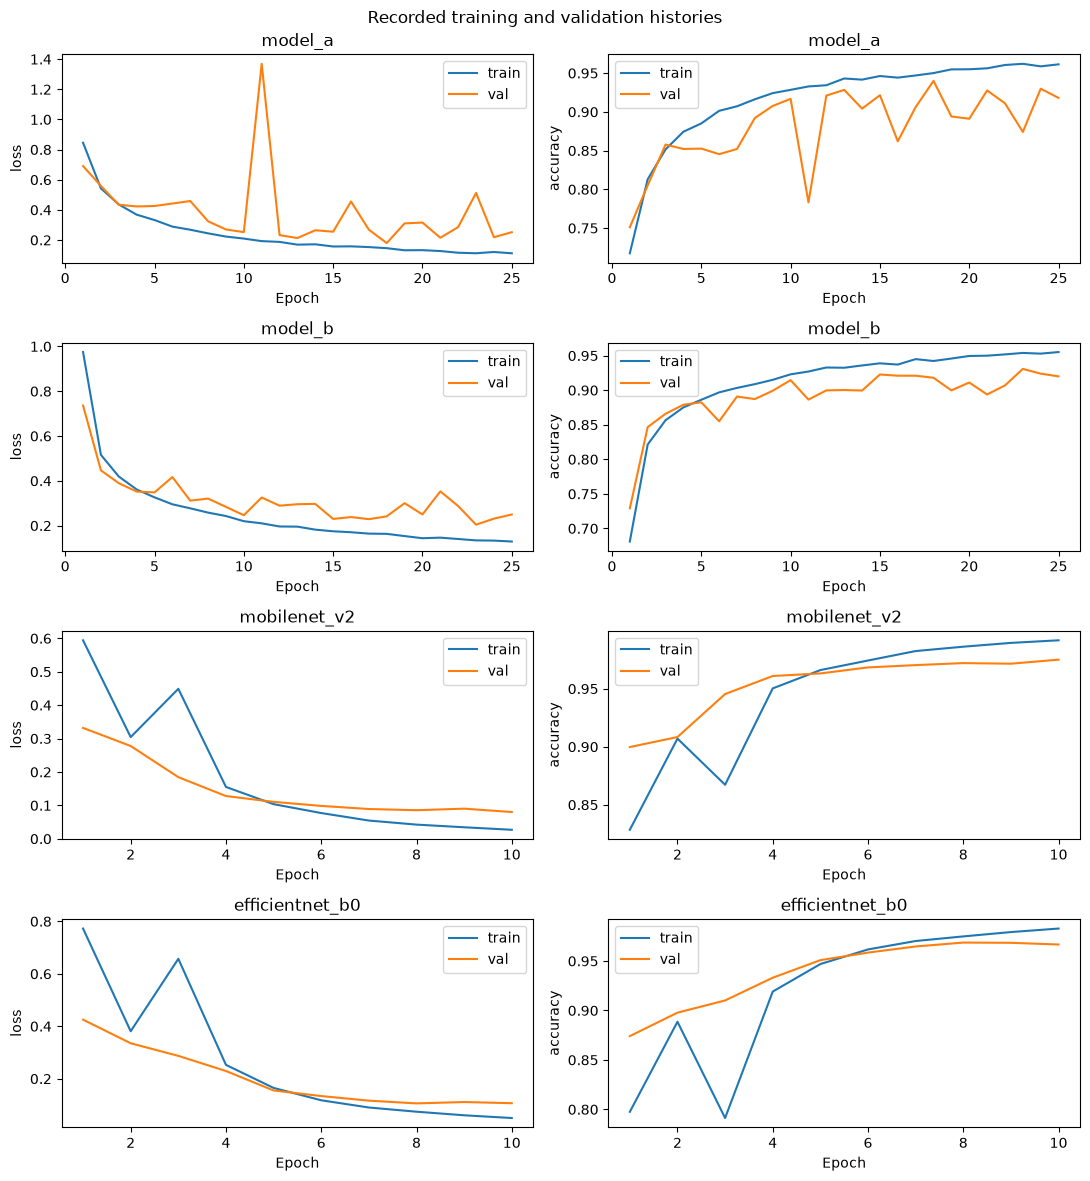

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(11, 12))
for row, name in enumerate(comparison.model):
    h = recorded_csv(f"results/raw/{name}/history.csv")
    for col, metric in enumerate(("loss", "accuracy")):
        ax = axes[row, col]
        for split in ("train", "val"):
            ax.plot(h.epoch, h[f"{split}_{metric}"], label=split)
        ax.set(title=name, xlabel="Epoch", ylabel=metric)
        ax.legend()
fig.suptitle("Recorded training and validation histories")
fig.tight_layout()
display(fig)
plt.close(fig)

### Recorded test confusion matrices
Each matrix contains the 4,050 held-out test samples. Rows denote true labels and columns predictions; the annotations are original integer counts.

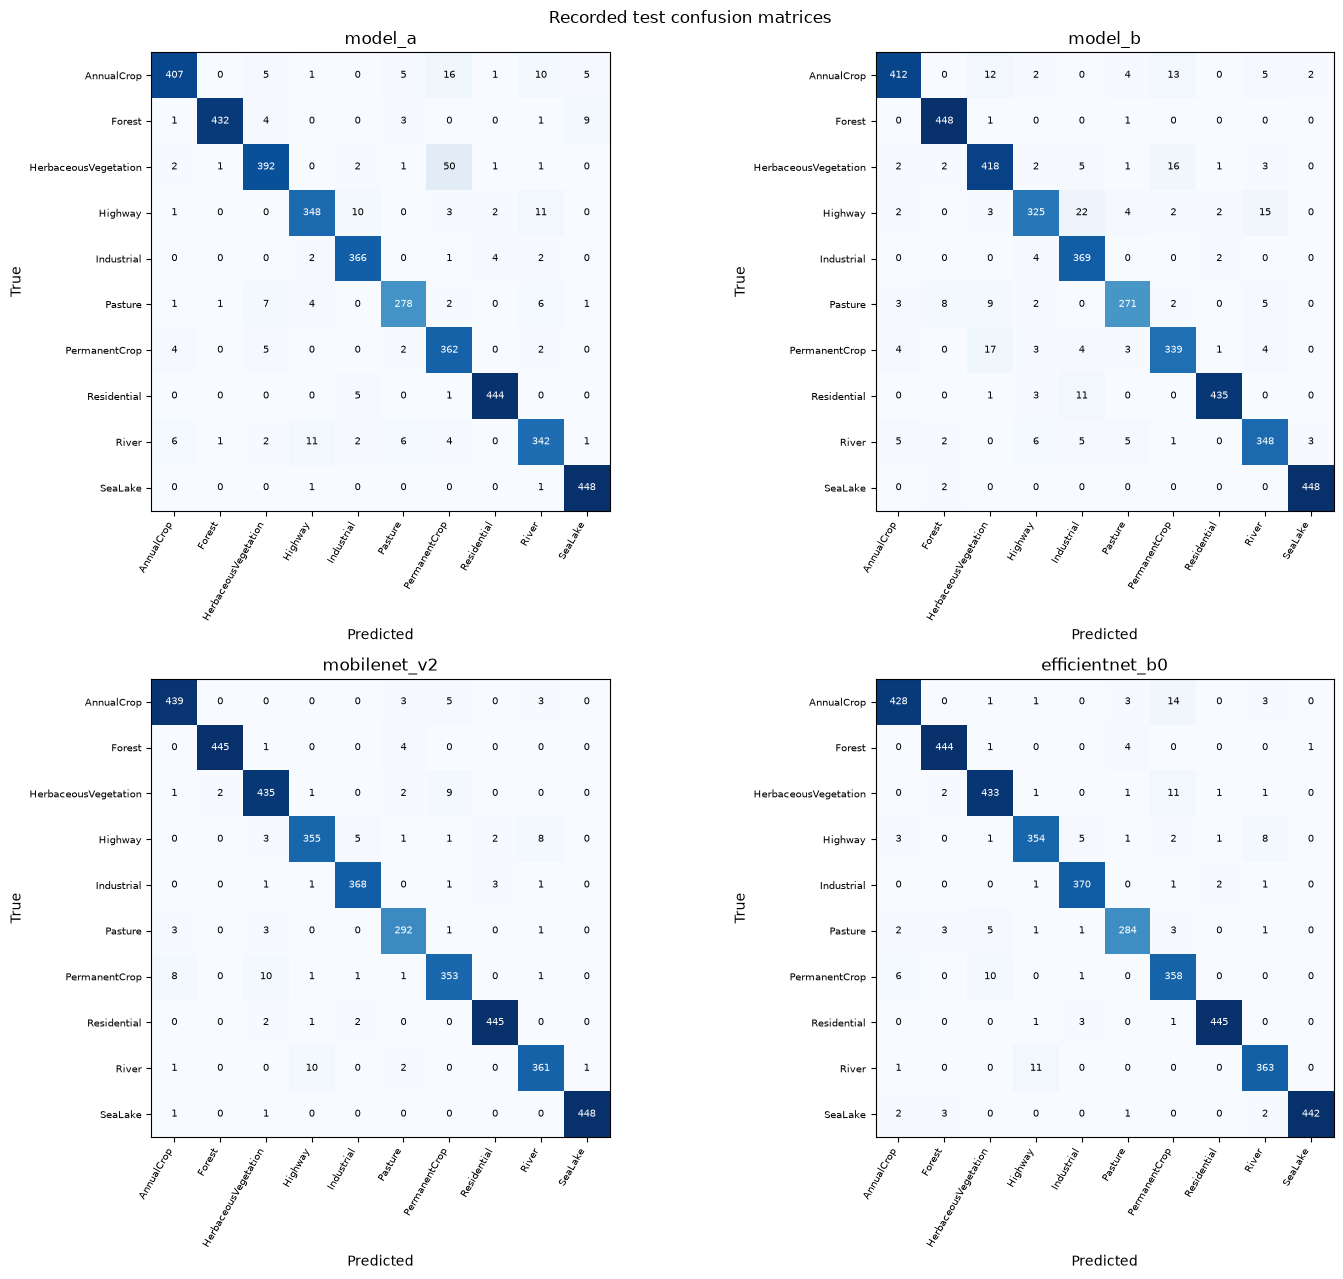

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
for ax, name in zip(axes.flat, comparison.model):
    cm = recorded_csv(f"results/raw/{name}/confusion_matrix.csv", index_col=0)
    ax.imshow(cm.to_numpy(), cmap="Blues")
    ax.set(title=name, xlabel="Predicted", ylabel="True", xticks=range(10), yticks=range(10), xticklabels=cm.columns, yticklabels=cm.index)
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=7)
    plt.setp(ax.get_yticklabels(), fontsize=7)
    for i in range(10):
        for j in range(10):
            v = cm.iloc[i,j]
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7, color="white" if v > cm.to_numpy().max()/2 else "black")
fig.suptitle("Recorded test confusion matrices")
fig.tight_layout()
display(fig)
plt.close(fig)

### Optimizer comparison and interpretation
The recorded pilots use identical initial weights and saved splits. Adam achieved the highest best validation accuracy with the tested settings, so it was selected for both custom models. Momentum improved SGD convergence in this pilot. Different learning-rate searches could change the ranking; the test set was not used for selection.

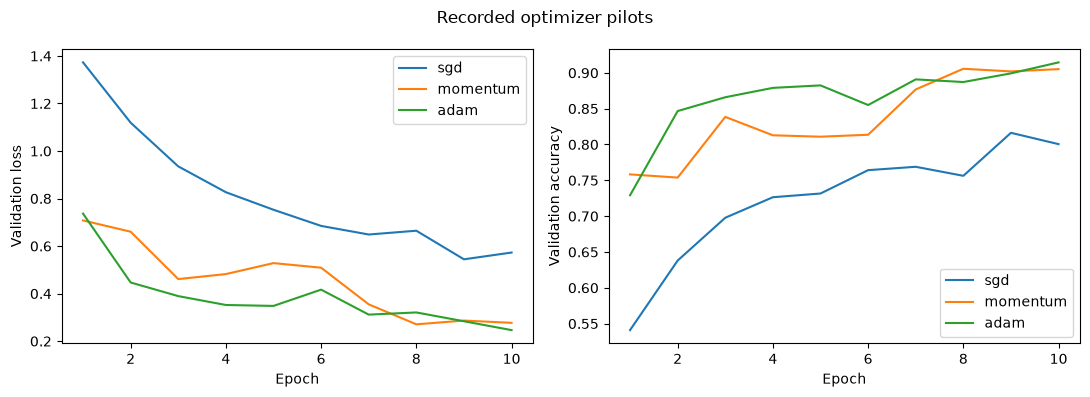

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in OPTIMIZERS:
    h = recorded_csv(f"results/raw/optimizer_{name}/history.csv")
    assert len(h) == OPTIMIZER_EPOCHS
    axes[0].plot(h.epoch, h.val_loss, label=name)
    axes[1].plot(h.epoch, h.val_accuracy, label=name)
for ax, ylabel in zip(axes, ("Validation loss", "Validation accuracy")):
    ax.set(xlabel="Epoch", ylabel=ylabel)
    ax.legend()
fig.suptitle("Recorded optimizer pilots")
fig.tight_layout()
display(fig)
plt.close(fig)

### Accuracy, memory and computational cost
Model B preserves most of Model A’s accuracy while substantially reducing parameter storage and convolution/linear arithmetic. Its smaller MAC count does not guarantee lower measured latency: depthwise kernels and memory access can limit performance. The recorded CPU timings and training epoch times should be interpreted for the original hardware, not as edge-device measurements.

The pretrained networks achieve higher test accuracy, but their parameter counts and checkpoint sizes exceed the custom sub-100k budget. MobileNetV2 has the highest recorded accuracy; EfficientNet-B0 has more parameters without an accuracy gain in this experiment. Parameter count, checkpoint storage and MACs describe different costs; peak activation RAM and energy were not measured.

In [22]:
table = comparison.set_index("model")
a, b = table.loc["model_a"], table.loc["model_b"]
print(f"Recorded Model A accuracy: {100*a.test_accuracy:.2f}%")
print(f"Recorded Model B accuracy: {100*b.test_accuracy:.2f}%")
print(f"Model B parameter reduction: {100*(1-b.total_parameters/a.total_parameters):.2f}%")
print(f"Model B MAC reduction: {100*(1-b.conv_linear_macs/a.conv_linear_macs):.2f}%")
print(f"Accuracy gap A minus B: {100*(a.test_accuracy-b.test_accuracy):.2f} percentage points")
for name in ("mobilenet_v2", "efficientnet_b0"):
    print(f"Recorded {name} accuracy: {100*table.loc[name, 'test_accuracy']:.2f}%")
print("Recorded run hardware:", recorded_json("results/raw/model_a/run.json")["device_name"])

Recorded Model A accuracy: 94.30%
Recorded Model B accuracy: 94.15%
Model B parameter reduction: 86.41%
Model B MAC reduction: 80.02%
Accuracy gap A minus B: 0.15 percentage points
Recorded mobilenet_v2 accuracy: 97.31%
Recorded efficientnet_b0 accuracy: 96.81%
Recorded run hardware: NVIDIA GeForce RTX 5060 Laptop GPU


## 13. Reproduction instructions
1. Install the dependencies listed above and open this notebook in Jupyter. Run all cells with the default flags to inspect embedded results and repeat lightweight checks. No local project files are needed.
2. Full reproduction is optional and was **not** performed when creating this submission. To request a fresh experiment yourself, choose a new relative `ROOT` directory, set `ALLOW_FULL_EXPERIMENTS=True`, and enable dataset preparation. The exact embedded split indices and manifest are retained; images download from EuroSAT. Network access and disk space are required.
3. Enable the optimizer experiment, custom training and pretrained training flags in that order. The original settings are ten epochs per optimizer, 25 per custom model, and two head plus eight fine-tuning epochs per pretrained model. ImageNet weights download only for actual transfer training.
4. Enable checkpoint evaluation after training to generate fresh predictions, metrics, confusion matrices, architecture tables, checkpoint sizes and latency measurements in the reproduction directory. The original recorded evidence displayed here remains unchanged. Completed runs are not overwritten silently.
5. Compare new results with the embedded evidence. Numerical reproducibility depends on library versions and hardware; recorded timings are not expected to match other machines.

Implementation definitions are inlined from the completed project. Notebook-only adaptations provide relative paths, opt-in guards, portable manifest comparison, and suppression of profile-file writes during smoke tests. No experiment configuration or model architecture was changed.